## Introduction 

In [10]:
# read() read all the file as string, and splitlines() splits by new line '/n'
names = open('names.txt', 'r').read().splitlines() 

In [13]:
names[:5], len(names)

(['emma', 'olivia', 'ava', 'isabella', 'sophia'], 32033)

In [14]:
min(names, key=len) # shortest name

'an'

In [16]:
max(names, key=len) # largest name

'muhammadibrahim'

### Character Level Language Model

<p style="font-size:18px;">
    <b>Intuition:</b> is to predict the next character in a sequence of characters.
    Take for example the name <code>Omar</code>. What can we extract from this name?
</p>

<ul style="font-size:18px;">
    <li>
        <b>O</b> — a character that most likely begins a name.
    </li>
    <li>
        <b>m</b> — a character that most likely follows <b>o</b> in a name.
    </li>
    <li>
        <b>a</b> — a character that most likely follows <b>m</b> in a given name.
    </li>
    <li>
        <b>r</b> — a character that most likely follows <b>a</b>, and also indicates the name ends
        (<span style="color: rgb(255, 148, 148);">
            i.e., there are no more characters and generation should stop
        </span>).
    </li>
</ul>

<p style="font-size:18px;">
    So it is a statistical model, based on frequency of characters. 
</p>


In [48]:
for w in names[:1]: # sliding window of size two charactes
    for w1, w2 in zip(w, w[1:]): 
        print(w1, w2)

e m
m m
m a


In [52]:
for w in names[:1]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>


In [53]:
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>
<S> o
o l
l i
i v
v i
i a
a <W>
<S> a
a v
v a
a <W>


<p style="font-size:18px;">
we then create a dictionary that counts each one of these Bigram, like what is the most likely character to follow <br>    <code> '< S >' </code>, that will be the most character that start a word, what is the most character that likely to follow, 
        a an arbitrary character m, etc. 
</p>




In [58]:
b = {}
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) # create a tuple
        
        b[bigram] = b.get(bigram, 0) + 1 
        # b.get() will check if bigram exist if not, return 0, instead of an error. And then add 1. 
    

In [57]:
b # ('a', '<W>'): 3 were the most likely pair of these 3 words, the 3 words ended with 'a'. 

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<W>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [59]:
b = {}
for w in names:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) 
        b[bigram] = b.get(bigram, 0) + 1 

In [74]:
max(b, key=b.get)

('n', '<W>')

In [75]:
b.get(('n', '<W>')) 

6763

<p style ="font-size:18ps;"> 6763 words ended with a character <b> n </b> </p>

In [76]:
min(b, key=b.get)

('q', 'r')

In [77]:
b.get(('n', 'r'))

44

<p style ="font-size:18ps;"> least frequent pair is<b> n </b> followed by <b> r </p>

In [80]:
sorted(b.items(), key=lambda x: x[1], reverse=True)

[(('n', '<W>'), 6763),
 (('a', '<W>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<W>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<W>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<W>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<W>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

## Create Bigram in a Tensor for efficiency

In [82]:
import torch

In [86]:
N = torch.zeros(28, 28, dtype=torch.int32) # all english alphabet plus <S> and <E>
# co-occurrence matrix of all alphabets with each other

In [93]:
alpha = sorted(list(set(''.join(names)))) 
# join all words into a single list, remove duplicated, sort it, we get all the alphabet ordered

In [100]:
# Then map each character into a number like a dict
# String into a index stoi
stoi = {s:i for i, s in enumerate(alpha)}
stoi['a']

0

In [104]:
# Then add two special characters 
stoi['<S>'] = 26
stoi['<E>'] = 27


In [108]:
# Use our look up table of each character, to index the tensor and count each letter
for w in names: 
    chs = ['<S>'] + list(w) + ['<E>']
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        N[index1, index2] += 1

In [112]:
import matplotlib.pyplot as plt
%matplotlib inline

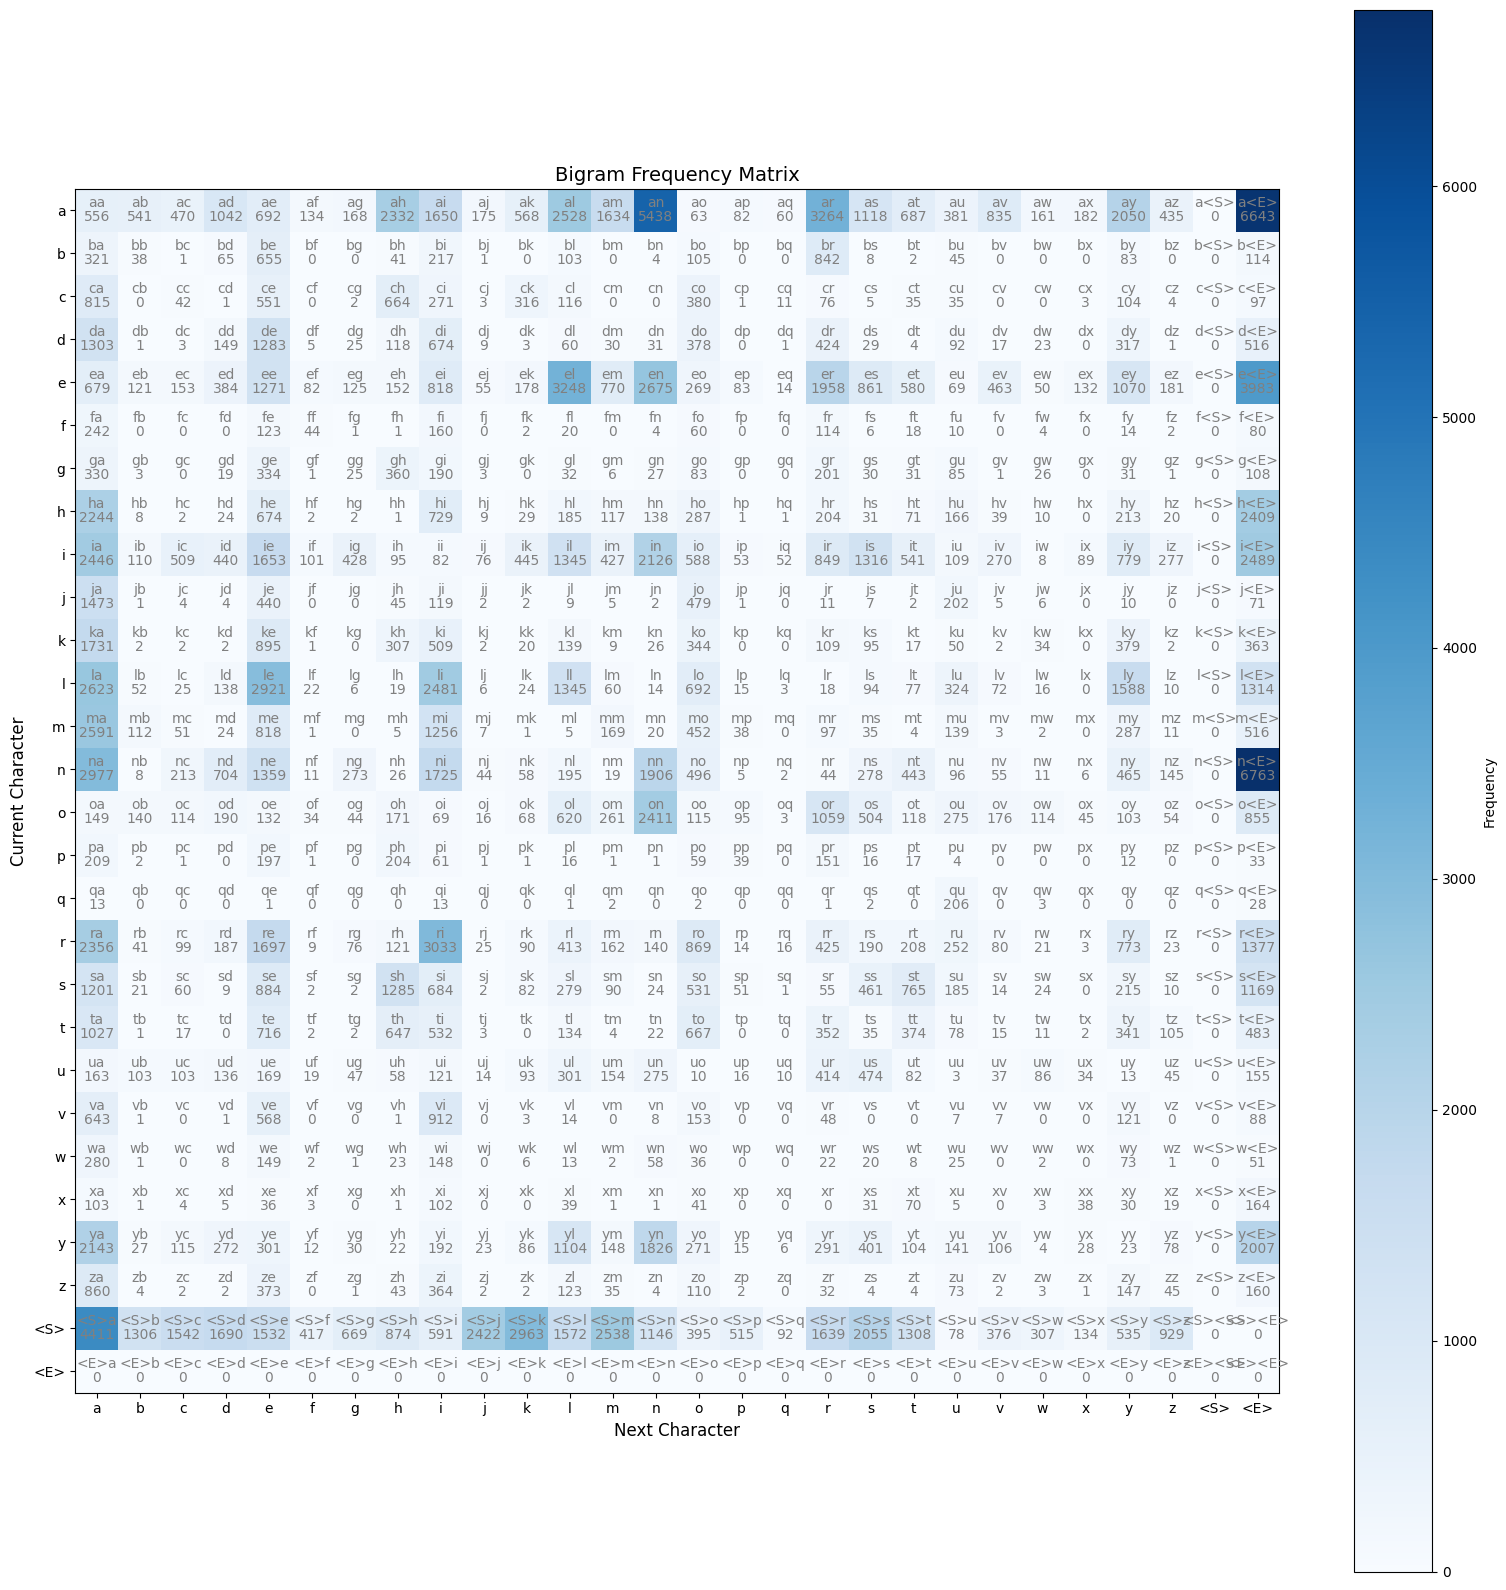

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

itos = {i: s for s, i in stoi.items()} # reverse index to string

for i in range(28):
    for j in range(28):
        bigram = itos[i] + itos[j] # two characters aa, ab, ac, etc
        
        count = N[i, j].item()  # .item() to extract number from tensor
        
        plt.text(j, i, bigram, ha="center", va="bottom", color='gray')
        plt.text(j, i, count, ha="center", va="top", color='gray')
        

plt.xticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.yticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.xlabel('Next Character', fontsize=12)
plt.ylabel('Current Character', fontsize=12)
plt.title('Bigram Frequency Matrix', fontsize=14)
plt.colorbar(label='Frequency')
plt.tight_layout()
plt.show()

### Interpreting the Matrix 

<p style="font-size:18px;"> As you can see the Last Row, <code>< E ></code> is starting zero times, because it is a special token that defines a end of a name. So it is starting zero times.<br> <br>
    Also the column before the ending <code> < S > </code> is also ending zero times. Because that is a special token to denote a the starting letter of a name. <br> </p>

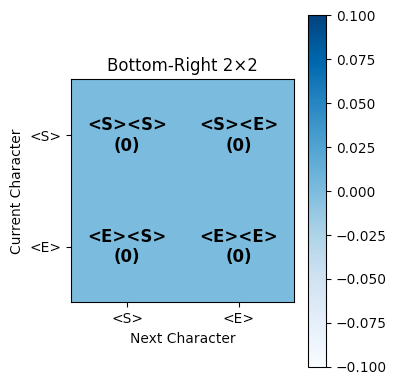